# Evaluator-Optimizer Pattern

The **Evaluator-Optimizer** pattern is an iterative workflow where one LLM call generates a response while another evaluates it in a loop. This pattern is particularly effective when:

- **Clear evaluation criteria exist** - You can define what makes a good response
- **Iterative refinement adds value** - Multiple attempts can measurably improve results
- **Cost vs. quality trade-offs matter** - More LLM calls yield better output

### How It Works
1. **Generator** creates an initial answer to the question
2. **Evaluator** judges if the answer meets quality standards
3. **Conditional Router** either:
   - Ends the workflow if satisfactory
   - Loops back to generator with feedback for improvement
4. **Loop Control** prevents infinite iterations with a max attempts limit

### Example Use Cases
- Literary translation (evaluator checks for accuracy and tone)
- Complex search tasks requiring multiple rounds
- Document generation with quality checks
- Code generation with review cycles

In [12]:
import os
from typing import TypedDict, Annotated, List, Dict, Any
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
import operator
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

load_dotenv()
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL")

# Initialize the LLM
llm = ChatOllama(model="minimax-m2.5:cloud", base_url=OLLAMA_BASE_URL)

## State Definition

Our state tracks:
- `question`: The original question to answer
- `answer`: The current generated answer
- `correct`: Whether the answer passes evaluation ('yes' or 'no')
- `feedback`: Detailed feedback from the evaluator
- `attempts`: Count of generation attempts to prevent infinite loops

In [13]:
class State(TypedDict):
    question: str
    answer: str
    correct: Literal["yes", "no"]
    feedback: str
    attempts: int

## Structured Output Schema

The evaluator will return structured output with a grade and feedback.

In [14]:
class Feedback(BaseModel):
    grade: Literal["yes", "no"] = Field(description="Whether the answer is satisfactory or not")
    feedback: str = Field(description="Detailed feedback on the answer. If unsatisfactory, explain what needs improvement.")

# Augment the LLM with schema for structured output
evaluator_llm = llm.with_structured_output(Feedback)

## Node Definitions

### 1. Generator Node
Creates or improves the answer based on the question and any previous feedback.

In [15]:
def generate_answer(state: State):
    """Generate or improve an answer based on feedback."""
    print(f"\n---GENERATION ATTEMPT {state['attempts'] + 1}---")
    
    # Build the prompt based on whether this is first attempt or revision
    if state["attempts"] == 0:
        # First attempt - generate initial answer
        messages = [
            SystemMessage(content="You are a helpful research assistant. Provide a comprehensive, accurate answer to the user's question."),
            HumanMessage(content=f"Question: {state['question']}\n\nProvide a detailed answer.")
        ]
    else:
        # Revision attempt - incorporate feedback
        messages = [
            SystemMessage(content="You are a helpful research assistant. Improve your previous answer based on the provided feedback."),
            HumanMessage(content=f"""Question: {state['question']}

Previous Answer: {state['answer']}

Feedback for Improvement: {state['feedback']}

Please provide an improved answer addressing the feedback.""")
        ]
    
    response = llm.invoke(messages)
    return {
        "answer": response.content,
        "attempts": state["attempts"] + 1
    }

### 2. Evaluator Node
Evaluates the quality of the generated answer and provides structured feedback.

In [16]:
def evaluate_answer(state: State):
    """Evaluate the quality of the generated answer."""
    print(f"---EVALUATING ANSWER (Attempt {state['attempts']})---")
    
    system_prompt = """You are a strict evaluator. You must respond with valid JSON only.

Your response must be in this exact format:
{\"grade\": \"yes\" or \"no\", \"feedback\": \"your detailed feedback here\"}

Do not use markdown formatting, bullet points, or any other formatting.
Return ONLY the JSON object."""

    evaluation_prompt = f"""Evaluate the following answer to the question.

Question: {state['question']}

Answer to Evaluate: {state['answer']}

Evaluate based on:
1. Accuracy - Is the information correct?
2. Completeness - Does it fully answer the question?
3. Clarity - Is it well-explained and easy to understand?"""
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=evaluation_prompt)
    ]
    result = evaluator_llm.invoke(messages)
    
    print(f"Grade: {result.grade}")
    print(f"Feedback: {result.feedback[:200]}...")
    
    return {
        "correct": result.grade,
        "feedback": result.feedback
    }

### 3. Router Function
Determines whether to continue the loop or end based on evaluation and attempt count.

In [17]:
def route_based_on_evaluation(state: State) -> str:
    """Route to END if answer is correct or max attempts reached."""
    max_attempts = 3
    
    if state["correct"] == "yes":
        print("\n✓ Answer is satisfactory. Ending workflow.")
        return END
    elif state["attempts"] >= max_attempts:
        print(f"\n⚠ Max attempts ({max_attempts}) reached. Ending workflow.")
        return END
    else:
        print(f"\n→ Answer needs improvement. Attempt {state['attempts']}/{max_attempts}. Looping back...")
        return "generate_answer"

## Graph Construction

Build the workflow with the generator, evaluator, and conditional routing.

In [18]:
# Initialize the graph
builder = StateGraph(State)

# Add nodes
builder.add_node("generate_answer", generate_answer)
builder.add_node("evaluate_answer", evaluate_answer)

# Add edges
builder.add_edge(START, "generate_answer")
builder.add_edge("generate_answer", "evaluate_answer")

# Add conditional edge for the loop
builder.add_conditional_edges(
    "evaluate_answer",
    route_based_on_evaluation,
    ["generate_answer", END]
)

# Compile the graph
graph = builder.compile()

## Visualize the Graph

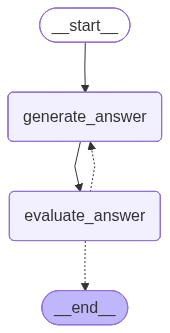

In [19]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    # Print Mermaid syntax as fallback
    print("\nGraph structure (Mermaid):")
    print(graph.get_graph().draw_mermaid())

## Example Execution

Let's test the Evaluator-Optimizer with a question that benefits from iterative refinement.

In [21]:
# Example 1: A question requiring a comprehensive answer
initial_state = {
    "question": "Explain the 5 key differences between Python lists and tuples, and when to use each. ",
    "answer": "",
    "correct": "no",
    "feedback": "",
    "attempts": 0
}

print("=" * 60)
print("RUNNING EVALUATOR-OPTIMIZER WORKFLOW")
print("=" * 60)
print(f"Question: {initial_state['question']}\n")

# Run the graph
result = graph.invoke(initial_state)

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)
print(f"\nFinal Answer (after {result['attempts']} attempt(s)):")
print(result["answer"])
print(f"\nFinal Grade: {result['correct']}")
print(f"Feedback: {result['feedback']}")

RUNNING EVALUATOR-OPTIMIZER WORKFLOW
Question: Explain the 5 key differences between Python lists and tuples, and when to use each. 


---GENERATION ATTEMPT 1---
---EVALUATING ANSWER (Attempt 1)---
Grade: yes
Feedback: The answer is excellent and fully meets all evaluation criteria. Accuracy: All 5 key differences are correctly stated - mutability (the core difference), syntax (square brackets vs parentheses), perfo...

✓ Answer is satisfactory. Ending workflow.

FINAL RESULT

Final Answer (after 1 attempt(s)):
Excellent question. Understanding the difference between lists and tuples is fundamental to writing efficient and correct Python code. Here are the 5 key differences, followed by guidance on when to use each.

### The 5 Key Differences

| Feature | List | Tuple |
| :--- | :--- | :--- |
| **1. Mutability (Core Difference)** | **Mutable.** You can modify, add, or remove elements after creation (e.g., `my_list.append(x)`, `my_list[0] = new_value`). | **Immutable.** Once created, yo

### Example 2: Complex Question

Let's try with a more complex question that might need multiple iterations.

In [ ]:
# Example 2: A more complex question
initial_state_2 = {
    "question": "What are the main differences between REST and GraphQL APIs? Include examples of when each is preferred.",
    "answer": "",
    "correct": "no",
    "feedback": "",
    "attempts": 0
}

print("=" * 60)
print("RUNNING EVALUATOR-OPTIMIZER WORKFLOW - EXAMPLE 2")
print("=" * 60)
print(f"Question: {initial_state_2['question']}\n")

# Run the graph
result_2 = graph.invoke(initial_state_2)

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)
print(f"\nFinal Answer (after {result_2['attempts']} attempt(s)):")
print(result_2["answer"][:500] + "..." if len(result_2["answer"]) > 500 else result_2["answer"])
print(f"\nFinal Grade: {result_2['correct']}")

## Streaming the Workflow

We can also stream the graph execution to see intermediate states.

In [22]:
# Stream the execution to see each step
initial_state_3 = {
    "question": "What is the difference between supervised and unsupervised learning in machine learning?",
    "answer": "",
    "correct": "no",
    "feedback": "",
    "attempts": 0
}

print("Streaming workflow execution:\n")
for event in graph.stream(initial_state_3):
    for node, state in event.items():
        if node != "__end__":
            print(f"\n>>> Step: {node}")
            if "answer" in state and state["answer"]:
                preview = state["answer"][:150].replace("\n", " ")
                print(f"    Answer preview: {preview}...")
            if "correct" in state and state["correct"]:
                print(f"    Grade: {state['correct']}")
            if "attempts" in state:
                print(f"    Attempts: {state['attempts']}")

print("\n✓ Workflow complete!")

Streaming workflow execution:


---GENERATION ATTEMPT 1---

>>> Step: generate_answer
    Answer preview: Excellent question. This is one of the most fundamental distinctions in machine learning. Here’s a detailed breakdown of the differences between super...
    Attempts: 1
---EVALUATING ANSWER (Attempt 1)---
Grade: yes
Feedback: This is an excellent, comprehensive answer that fully addresses the question. The answer is accurate - all technical definitions, algorithms, and problem types are correctly stated. It is complete - c...

✓ Answer is satisfactory. Ending workflow.

>>> Step: evaluate_answer
    Grade: yes

✓ Workflow complete!


## Key Takeaways

The Evaluator-Optimizer pattern provides several advantages:

1. **Quality Assurance**: Iterative refinement ensures higher quality outputs
2. **Automatic Correction**: The system can self-correct based on feedback
3. **Configurable Limits**: Max attempts prevent infinite loops
4. **Transparent Process**: Each iteration is visible and traceable
5. **Flexible Evaluation**: Evaluation criteria can be customized for specific domains

### When to Use
- Literary translation with quality checks
- Complex search and research tasks
- Document generation requiring accuracy
- Code generation with automated review

### When NOT to Use
- Simple tasks where one LLM call is sufficient
- Latency-sensitive applications
- When evaluation criteria are ambiguous